# 06 Sonar Basics, Propagation, and Time of Flight

## Purpose

This notebook begins the sonar-specific part of the curriculum. The goal is to connect the signal-processing ideas from the earlier notebooks to simple acoustic ranging: sound propagates at a finite speed, echoes return after a delay, and that delay encodes target range.

## Prerequisites

- Notebook 01: Signals, Systems, and Sampling
- Notebook 04: Convolution, Filtering, and Matched Filters
- Notebook 05: Noise, Detection, and Estimation
- Basic comfort with distance, speed, and time relationships

## Learning Objectives

By the end of this notebook, you should be able to:

- explain why sonar range measurement is fundamentally a time-delay problem,
- compute round-trip travel time from range and sound speed,
- relate receive-window timing to maximum unambiguous range,
- interpret simple transmitted and received pulse plots,
- and connect delay estimation to later pulse-compression and ranging notebooks.



## New Terms In This Notebook

- **Monostatic sonar**: a sonar configuration in which the transmitter and receiver are at the same location.
- **Propagation speed**: the speed at which the acoustic wave travels through the medium.
- **Time of flight (TOF)**: the travel time between transmission and reception.
- **Round-trip delay**: the total transmit-to-target-to-receiver travel time.
- **Range**: the distance from the sonar to the target.
- **Receive record**: the finite block of received samples that we analyze together.
- **Receive window**: the time interval over which the receiver listens for echoes after transmission.
- **Maximum unambiguous range**: the largest range that can be measured before a later echo would overlap with the next transmit event or fall outside the intended receive window.
- **Echo**: the returned version of the transmitted pulse after reflection from a target.
- **Point target**: an idealized target treated as if all reflection comes from one location.
- **Two-way travel**: propagation from sonar to target and back again.


## Big Picture

Earlier notebooks focused on how signals behave in time and frequency. This notebook asks a sonar-specific question: if we transmit a pulse into the water and receive an echo later, what does that delay tell us about the scene?

The big idea is simple: sonar ranging starts with geometry and finite propagation speed. A matched filter can help us measure delay, but the physical meaning of that delay comes from two-way travel time. That is the bridge from generic signal processing to actual sensing.



## Mathematical Definitions and Relevant Intuition

### Round-Trip Time Of Flight

For a monostatic sonar observing a target at range $R$ in a medium with propagation speed $c$, the round-trip time of flight is

$$
\tau = \frac{2R}{c}.
$$

The factor of 2 matters because the sound must travel to the target and then back to the receiver.

### Range From Measured Delay

If we estimate the round-trip delay $\tau$, then the corresponding range is

$$
R = \frac{c\tau}{2}.
$$

This is the core ranging equation for the simple monostatic case.

### Sample Delay In A Discrete Record

Once we sample the received signal at sample rate $f_s$, the same delay appears as an offset in samples:

$$
n_{delay} \approx \tau f_s.
$$

In code we usually round this to the nearest integer sample. That is why later figures can show the same delay as time in milliseconds, lag in samples, or range in meters.

### Receive-Window And Maximum Range

If the receiver listens for only a finite duration $T_{listen}$ after transmission, then the largest range that can still be observed in that window is

$$
R_{max} = \frac{c T_{listen}}{2}.
$$

This is one reason timing choices matter in sonar system design: a longer receive window allows more distant echoes, but it also affects update rate and ambiguity.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from _bootstrap import bootstrap_src_path

bootstrap_src_path()

from sonar_py_lib.dsp import estimate_delay_samples, matched_filter, normalize, time_axis
from sonar_py_lib.notebook_utils import set_plot_style
from sonar_py_lib.plotting import make_figure, plot_signal

set_plot_style()


def pulse_train(num_samples: int, start_idx: int, width: int, amplitude: float = 1.0) -> np.ndarray:
    x = np.zeros(num_samples, dtype=float)
    stop_idx = min(num_samples, start_idx + width)
    x[start_idx:stop_idx] = amplitude
    return x


## Assumptions

- We use monostatic geometry with one idealized point target.
- We use a fixed propagation speed rather than modeling depth, temperature, or salinity variation.
- We begin with rectangular pulses because their timing is easy to see visually.
- We stay in one dimension and focus on range, not bearing or image formation.


## Geometry Turns Range Into Delay

The first figure is meant to show the basic two-way relationship between range and time of flight. We sweep target range while holding sound speed fixed.

The lesson to watch for is linearity: doubling the target range doubles the round-trip delay. The mapping is simple, but that simplicity is exactly why accurate timing matters so much in sonar.


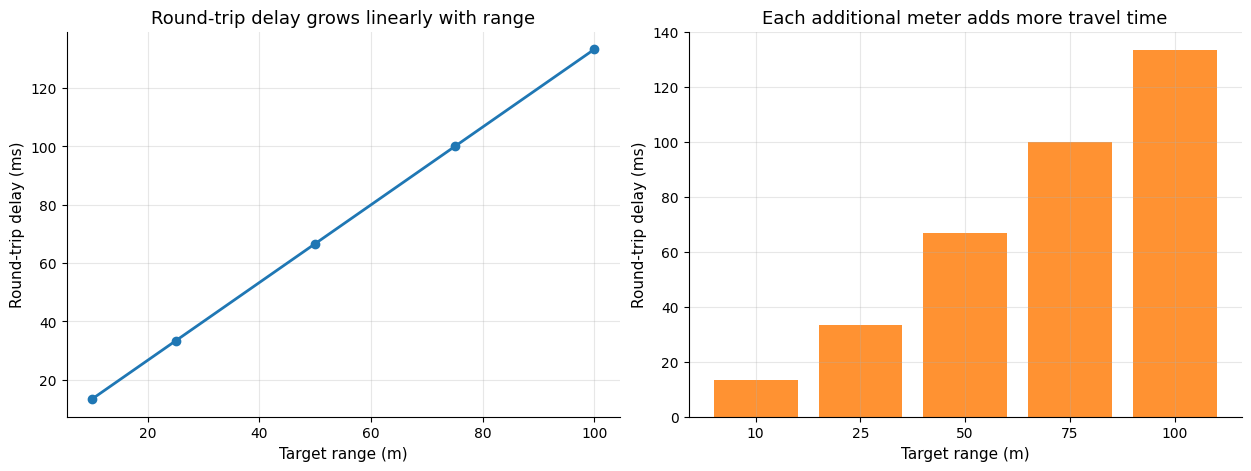

Range  10.0 m -> round-trip delay  13.33 ms
Range  25.0 m -> round-trip delay  33.33 ms
Range  50.0 m -> round-trip delay  66.67 ms
Range  75.0 m -> round-trip delay 100.00 ms
Range 100.0 m -> round-trip delay 133.33 ms


In [2]:
c_sound = 1500.0  # m/s, typical simple seawater value
ranges_m = np.array([10.0, 25.0, 50.0, 75.0, 100.0])
tof_ms = 1000.0 * (2.0 * ranges_m / c_sound)

fig, axes = make_figure(nrows=1, ncols=2, figsize=(12.4, 4.6), sharex=False)
axes[0].plot(ranges_m, tof_ms, marker="o", linewidth=2.0, color="C0")
axes[0].set_title("Round-trip delay grows linearly with range")
axes[0].set_xlabel("Target range (m)")
axes[0].set_ylabel("Round-trip delay (ms)")

axes[1].bar(ranges_m.astype(int).astype(str), tof_ms, color="C1", alpha=0.85)
axes[1].set_title("Each additional meter adds more travel time")
axes[1].set_xlabel("Target range (m)")
axes[1].set_ylabel("Round-trip delay (ms)")

plt.show()

for r, tau in zip(ranges_m, tof_ms):
    print(f"Range {r:>5.1f} m -> round-trip delay {tau:>6.2f} ms")


Because the delay is proportional to range, sonar ranging becomes a timing problem: estimate the echo delay accurately, then convert it to distance with the propagation speed.

The factor of 2 should remain visible in your thinking throughout the sonar notebooks. A measured delay is a two-way delay, so range is only half of the total travel distance.



## A Transmitted Pulse And Its Echo

The next figure is meant to show how a transmitted pulse and a delayed echo appear in a simple receive record.

The key things to notice are the transmit start time, the reflection event at the target, the echo arrival time at the receiver, and the two one-way travel arrows between them. In this simple point-target picture, the reflection event is shown halfway through the round-trip delay. The full separation from transmit start to echo arrival is the round-trip delay that carries the range information.


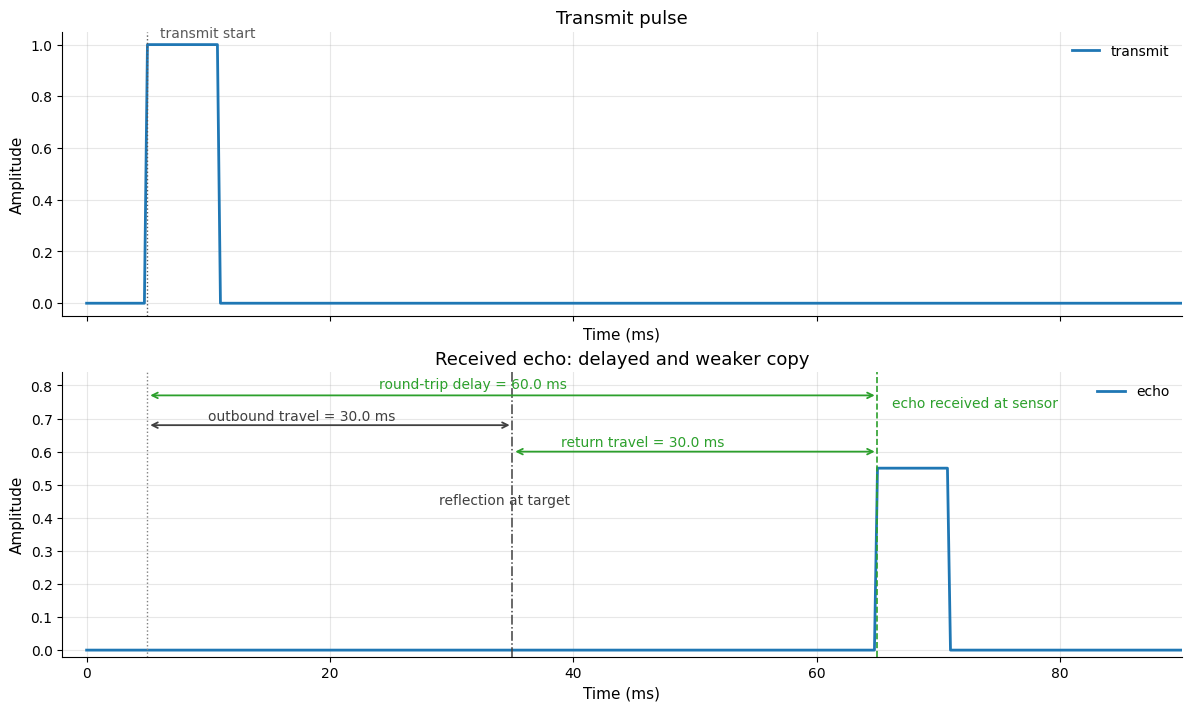

Target range: 45.0 m
Round-trip delay: 60.00 ms
Rounded sample delay: 240 samples


In [3]:

fs = 4000.0
record_duration_s = 0.20
num_samples = int(fs * record_duration_s)
t = time_axis(num_samples, fs)

pulse_width_s = 0.006
pulse_width_n = int(round(pulse_width_s * fs))
tx_start = 20
transmit = pulse_train(num_samples, tx_start, pulse_width_n, amplitude=1.0)

target_range_m = 45.0
delay_s = 2.0 * target_range_m / c_sound
delay_n = int(round(delay_s * fs))
delay_ms = 1000.0 * delay_n / fs
tx_start_ms = 1000.0 * (tx_start / fs)
echo_start_ms = 1000.0 * ((tx_start + delay_n) / fs)
midpoint_ms = 0.5 * (tx_start_ms + echo_start_ms)
outbound_ms = midpoint_ms - tx_start_ms
return_ms = echo_start_ms - midpoint_ms
receive = pulse_train(num_samples, tx_start + delay_n, pulse_width_n, amplitude=0.55)
display_end_ms = min(100.0, echo_start_ms + 25.0)

fig, axes = make_figure(nrows=2, ncols=1, figsize=(11.8, 7.0), sharex=True)
plot_signal(t * 1000.0, transmit, ax=axes[0], title="Transmit pulse", xlabel="Time (ms)", ylabel="Amplitude", label="transmit")
axes[0].axvline(tx_start_ms, color="0.35", linestyle=":", linewidth=1.0)
axes[0].text(tx_start_ms + 1.0, 1.03, "transmit start", color="0.35")
axes[0].set_xlim(-2.0, display_end_ms)
axes[0].legend(loc="upper right")

plot_signal(t * 1000.0, receive, ax=axes[1], title="Received echo: delayed and weaker copy", xlabel="Time (ms)", ylabel="Amplitude", label="echo")
axes[1].set_ylim(-0.02, 0.84)
axes[1].axvline(tx_start_ms, color="0.5", linestyle=":", linewidth=1.0)
axes[1].axvline(midpoint_ms, color="0.25", linestyle="-.", linewidth=1.1)
axes[1].axvline(echo_start_ms, color="C2", linestyle="--", linewidth=1.2)

axes[1].annotate("", xy=(echo_start_ms, 0.77), xytext=(tx_start_ms, 0.77), arrowprops=dict(arrowstyle="<->", color="C2", linewidth=1.3))
axes[1].annotate("", xy=(midpoint_ms, 0.68), xytext=(tx_start_ms, 0.68), arrowprops=dict(arrowstyle="<->", color="0.25", linewidth=1.3))
axes[1].annotate("", xy=(echo_start_ms, 0.60), xytext=(midpoint_ms, 0.60), arrowprops=dict(arrowstyle="<->", color="C2", linewidth=1.3))

axes[1].text((tx_start_ms + echo_start_ms) / 2.0 - 11.0, 0.79, f"round-trip delay = {delay_ms:.1f} ms", color="C2")
axes[1].text(tx_start_ms + 5.0, 0.695, f"outbound travel = {outbound_ms:.1f} ms", color="0.25")
axes[1].text(midpoint_ms + 4.0, 0.615, f"return travel = {return_ms:.1f} ms", color="C2")
axes[1].text(midpoint_ms - 6.0, 0.44, "reflection at target", color="0.25")
axes[1].text(echo_start_ms + 1.2, 0.735, "echo received at sensor", color="C2")
axes[1].set_xlim(-2.0, display_end_ms)
axes[1].legend(loc="upper right")
plt.show()

print(f"Target range: {target_range_m:.1f} m")
print(f"Round-trip delay: {1000.0 * delay_s:.2f} ms")
print(f"Rounded sample delay: {delay_n} samples")



In this idealized example, the echo keeps the same pulse shape and only changes in delay and amplitude. The three arrows separate the timing picture into outbound travel to the target, return travel back to the receiver, and the full round-trip delay.

The reflection marker is still conceptual rather than directly measured in the receive record, but it helps separate the physical propagation story into transmit, reflect, and receive stages.



## Delay Estimation Connects The Signal To The Geometry

The next figure is meant to show the bridge from signal processing back to physical range. We place the echo inside a noisy receive record, apply the matched filter, estimate the echo arrival time, and then convert the delay relative to transmit start into range.

The important things to watch are the marked true echo arrival time in the top panel and the true-versus-estimated round-trip delay markers in the bottom panel. The matched-filter peak becomes physically meaningful only after we measure it relative to the transmit start time.


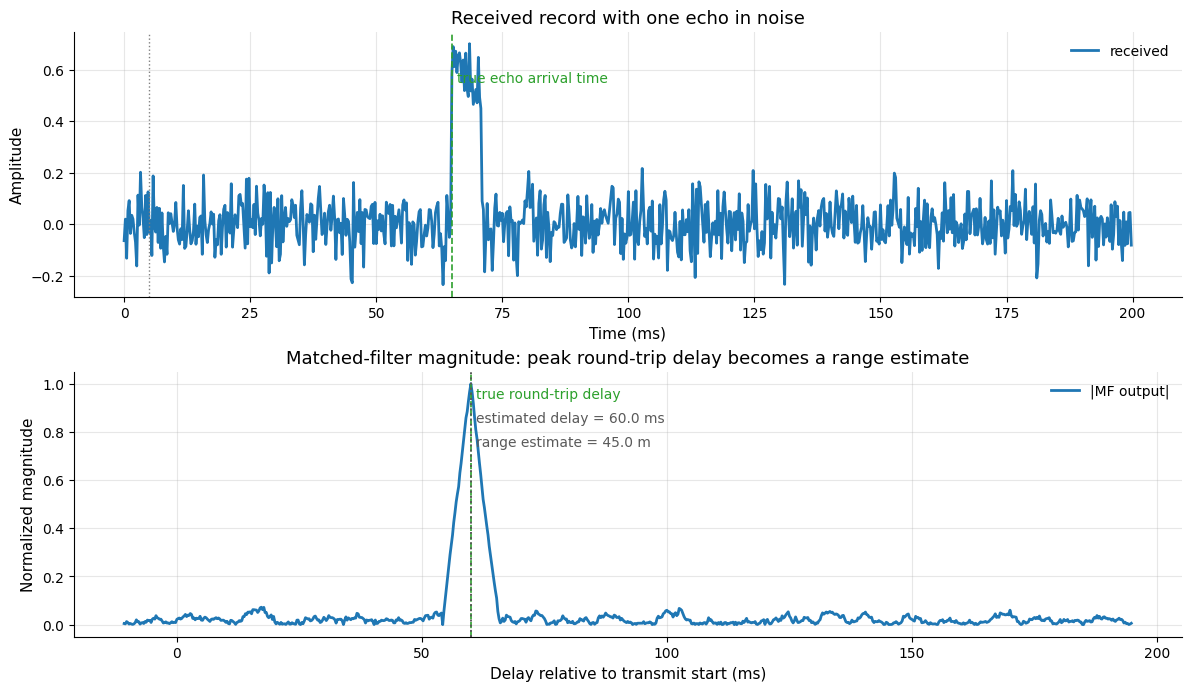

Matched-filter peak location: 260 samples from record start
True round-trip delay: 240 samples (60.00 ms)
Estimated round-trip delay: 240 samples (60.00 ms)
Estimated range: 45.00 m


In [4]:

rng = np.random.default_rng(9)
received_noisy = receive + 0.08 * rng.normal(size=num_samples)
mf = matched_filter(received_noisy, transmit[tx_start:tx_start + pulse_width_n], mode="full")
lags = np.arange(-(pulse_width_n - 1), len(received_noisy))
delay_axis_ms = 1000.0 * (lags - tx_start) / fs
peak_location_n = estimate_delay_samples(received_noisy, transmit[tx_start:tx_start + pulse_width_n])
delay_est_n = peak_location_n - tx_start
delay_est_ms = 1000.0 * delay_est_n / fs
range_est_m = c_sound * (delay_est_n / fs) / 2.0

fig, axes = make_figure(nrows=2, ncols=1, figsize=(11.8, 6.8), sharex=False)
plot_signal(t * 1000.0, received_noisy, ax=axes[0], title="Received record with one echo in noise", xlabel="Time (ms)", ylabel="Amplitude", label="received")
axes[0].axvline(tx_start_ms, color="0.5", linestyle=":", linewidth=1.0)
axes[0].axvline(echo_start_ms, color="C2", linestyle="--", linewidth=1.2)
axes[0].text(echo_start_ms + 1.0, 0.55, "true echo arrival time", color="C2")
axes[0].legend(loc="upper right")

plot_signal(delay_axis_ms, normalize(np.abs(mf)), ax=axes[1], title="Matched-filter magnitude: peak round-trip delay becomes a range estimate", xlabel="Delay relative to transmit start (ms)", ylabel="Normalized magnitude", label="|MF output|")
axes[1].axvline(delay_ms, color="C2", linestyle="--", linewidth=1.2)
axes[1].axvline(delay_est_ms, color="0.35", linestyle=":", linewidth=1.4)
axes[1].text(delay_ms + 1.0, 0.94, "true round-trip delay", color="C2")
axes[1].text(delay_est_ms + 1.0, 0.84, f"estimated delay = {delay_est_ms:.1f} ms", color="0.35")
axes[1].text(delay_est_ms + 1.0, 0.74, f"range estimate = {range_est_m:.1f} m", color="0.35")
axes[1].legend(loc="upper right")
plt.show()

print(f"Matched-filter peak location: {peak_location_n} samples from record start")
print(f"True round-trip delay: {delay_n} samples ({delay_ms:.2f} ms)")
print(f"Estimated round-trip delay: {delay_est_n} samples ({delay_est_ms:.2f} ms)")
print(f"Estimated range: {range_est_m:.2f} m")



This is the key bridge to later range-processing notebooks. The top panel shows when the echo actually arrives back at the receiver, and the bottom panel re-expresses the matched-filter peak as delay measured from the transmit start time.

Once that relative delay matches the true round-trip delay, the conversion to range is immediate through  = c	au / 2$. That is the basic ranging loop for simple active sonar.


## Receive Window Sets Maximum Unambiguous Range

The final figure is meant to show why timing design affects what ranges are observable. If the receive window is too short, distant echoes arrive too late and are simply missed.

The point to notice is that a sonar system is not only measuring echoes. It is also choosing when to listen. That timing choice sets a hard limit on the ranges that can be observed cleanly in this simple model.


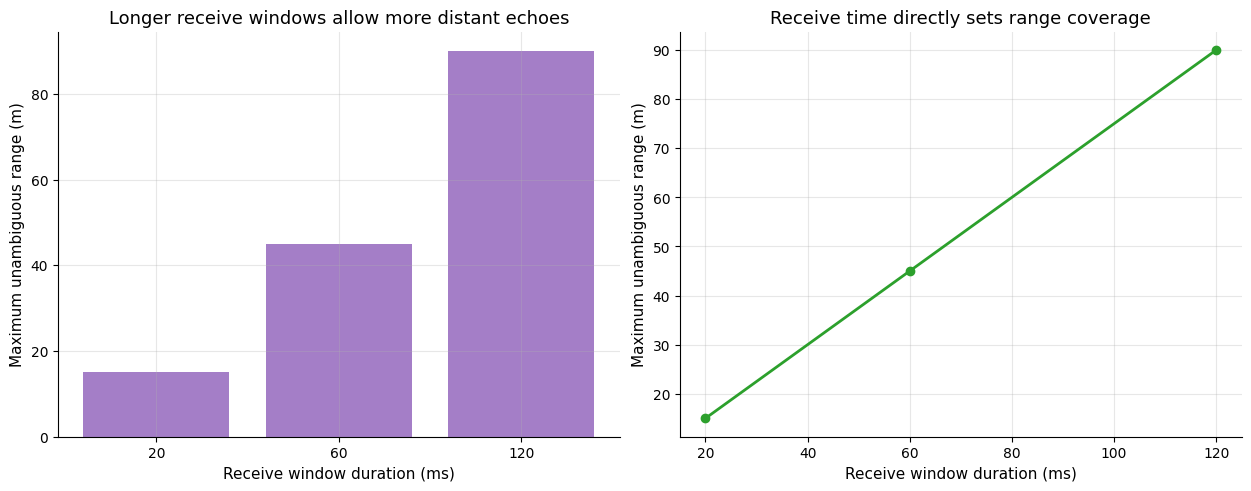

Listen window  20.0 ms -> max range   15.0 m
Listen window  60.0 ms -> max range   45.0 m
Listen window 120.0 ms -> max range   90.0 m


In [5]:
listen_windows_ms = np.array([20.0, 60.0, 120.0])
max_ranges_m = c_sound * (listen_windows_ms / 1000.0) / 2.0

fig, axes = make_figure(nrows=1, ncols=2, figsize=(12.4, 4.8), sharex=False)
axes[0].bar(listen_windows_ms.astype(int).astype(str), max_ranges_m, color="C4", alpha=0.85)
axes[0].set_title("Longer receive windows allow more distant echoes")
axes[0].set_xlabel("Receive window duration (ms)")
axes[0].set_ylabel("Maximum unambiguous range (m)")

axes[1].plot(listen_windows_ms, max_ranges_m, marker="o", linewidth=2.0, color="C2")
axes[1].set_title("Receive time directly sets range coverage")
axes[1].set_xlabel("Receive window duration (ms)")
axes[1].set_ylabel("Maximum unambiguous range (m)")

plt.show()

for tw, rm in zip(listen_windows_ms, max_ranges_m):
    print(f"Listen window {tw:>5.1f} ms -> max range {rm:>6.1f} m")


A longer receive window allows more distant targets, but it also means the system is spending more time waiting for late echoes. In later notebooks, that simple timing tradeoff will interact with pulse repetition, ambiguity, and update rate.


## Tradeoffs And Limitations

Several practical tradeoffs are already visible in this simplified notebook:

- Longer receive windows allow more range coverage but reduce how quickly the system can move on to the next listening interval.
- Delay estimation becomes more useful when the pulse is easy to detect, but noise and distortion can degrade the estimate.
- A fixed sound speed makes the geometry simple, but real propagation speed can vary with the environment.
- Ideal point-target echoes are easy to interpret, but real scenes may contain multiple reflectors and overlapping returns.

This notebook also leaves out several important realities:

- transmit/receive blanking and hardware constraints,
- beam pattern effects,
- multipath,
- and pulse-compression details.


## Recap

- Monostatic sonar range measurement starts with two-way travel time.
- The basic ranging equation is $R = c\tau / 2$.
- Echoes can be modeled first as delayed copies of the transmitted pulse.
- A matched-filter peak gives a delay estimate, and that delay estimate maps to range.
- Receive-window timing sets a maximum observable range in the simple model.


## Suggested Next Questions

- How do chirps and pulse compression improve range resolution?
- How do bandwidth and pulse duration trade off against one another?
- What changes when multiple targets return overlapping echoes?

The next notebook turns to chirps, pulse compression, and range resolution.
